In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import glob
from tqdm.auto import tqdm
import numpy as np
import os
import json

from semantic_state_estimator.constants import (
    RENDERS_DIR,
    TRUE_STATES_DIR,
    PROCESSED_DIR
)

def load_all(data_dir):
    seeds = os.listdir(os.path.join(data_dir, PROCESSED_DIR))

    all_renders = {}
    gts = {}
    preds = {seed: {} for seed in seeds}
    for renders_file in tqdm(glob.glob(os.path.join(data_dir, RENDERS_DIR, '*.npz'))):
        dp_name = os.path.splitext(os.path.basename(renders_file))[0]

        with np.load(renders_file) as data:
            all_renders[dp_name] = {k: data[k] for k in data}
        
        gt_path = os.path.join(data_dir, TRUE_STATES_DIR, dp_name + '.json')
        if os.path.exists(gt_path):
            with open(gt_path, 'r') as f:
                gts[dp_name] = json.load(f)
    
        for seed in seeds:
            pred_path = os.path.join(data_dir, PROCESSED_DIR, str(seed), dp_name + '.json')
            if os.path.exists(pred_path):
                with open(pred_path, 'r') as f:
                    preds[seed][dp_name] = json.load(f)
                first_item = next(iter(preds[seed][dp_name].values()))
                if isinstance(first_item, dict):
                    means = defaultdict(int)
                    num_viewpoints = len(preds[seed][dp_name])
                    for k, v in  preds[seed][dp_name].items():
                        preds.setdefault(seed + ' ' + k, {})[dp_name] = v
                        for predicate, score in v.items():
                            means[predicate] += score / num_viewpoints
                    preds[seed][dp_name] = means

    return all_renders, gts, preds

all_renders, gts, preds = load_all('examples/real_robot/data_dir')

  0%|          | 0/1001 [00:00<?, ?it/s]

In [3]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    classification_report
)
import numpy as np
from itertools import combinations

from semantic_state_estimator.utils.statistics import acc_curve_with_cooc_mat, ap_score_with_cooc_mat
from semantic_state_estimator.utils.misc import squash_predicate


def collect_metrics(ground_truths, predicted_scores, cooc_mat=None, ignore_for_prec=None):
    ignore_for_prec = ignore_for_prec or []
    
    # sqash to array format
    filtered_gts = {k: {kp: vp for kp, vp in v.items() if kp not in ignore_for_prec} for k, v in ground_truths.items() if k in predicted_scores}
    filtered_preds = {k: {kp: vp for kp, vp in v.items() if kp not in ignore_for_prec} for k, v in predicted_scores.items()}
    y = squash_predicate(filtered_gts)
    y_score = squash_predicate(filtered_preds)

    # map predicates in alphabetical order for consistency
    pred_to_idx = {pred: i for i, pred in enumerate(sorted(next(iter(filtered_gts.values()))))}

    # instantiate output containters
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {},
    thresh_cooc = {}
    ap_cooc = {}

    # iterate predicates
    for pred, i in pred_to_idx.items():
        precision[pred], recall[pred], thresholds[pred] = precision_recall_curve(y[:, i], y_score[:, i])
        average_precision[pred] = average_precision_score(y[:, i], y_score[:, i])
        thresholds[pred] = np.concatenate([thresholds[pred], [1]])  # last threshold is omitted. add it back

    # accuracy (based on accuracy score from sklearn) curve and my custom AP implementation
    accuracy, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100)
    if cooc_mat is not None:
        # only need this for comparison if using cooccurrence
        ap, prec, rec, thresh = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, ignored_keys=ignore_for_prec)

        acc_cooc, _ = acc_curve_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat)
        ap_cooc, prec_cooc, rec_cooc, thresh_cooc = ap_score_with_cooc_mat(ground_truths, predicted_scores, num_thresholds=100, cooc_mat=cooc_mat,
                                                                           ignored_keys=ignore_for_prec)

    # average_precision['macro average'] = average_precision_score(y, y_score, average='macro')
    average_precision['micro average'] = average_precision_score(y, y_score, average='micro')
    average_precision['macro average'] = np.mean(list(average_precision.values()))

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

def collect_metrics_all_models(ground_truths, predicted_scores_all_models, cooc_mat=None, ignore_for_prec=None):
    accuracy = {}
    precision = {}
    recall = {}
    thresholds = {}
    average_precision = {}
    prec = {}
    rec = {}
    thresh = {}
    ap = {}
    acc_cooc = {}
    prec_cooc = {}
    rec_cooc = {}
    thresh_cooc = {}
    ap_cooc = {}
    
    for model, predicted_scores in tqdm(predicted_scores_all_models.items()):
        (
            accuracy[model],
            precision[model],
            recall[model],
            thresholds[model],
            average_precision[model],
            prec[model],
            rec[model],
            thresh[model],
            ap[model],
            acc_cooc[model],
            prec_cooc[model],
            rec_cooc[model],
            thresh_cooc[model],
            ap_cooc[model]
        ) = collect_metrics(ground_truths, predicted_scores, cooc_mat, ignore_for_prec)

    return (
        accuracy,
        precision,
        recall,
        thresholds,
        average_precision,
        prec,
        rec,
        thresh,
        ap,
        acc_cooc,
        prec_cooc,
        rec_cooc,
        thresh_cooc,
        ap_cooc
    )

In [4]:
from semantic_state_estimator.utils.statistics import get_cooccurrence_matrix
cooc_mat = None#get_cooccurrence_matrix('stam2')

In [5]:
(
    accuracy,
    precision,
    recall,
    thresholds,
    average_precision,
    prec,
    rec,
    thresh,
    ap,
    acc_cooc,
    prec_cooc,
    rec_cooc,
    thresh_cooc,
    ap_cooc
) = collect_metrics_all_models(gts, preds, cooc_mat,
                              ignore_for_prec=[
                                  'in-table-section(green-mug,blue)',
                                  'robot-holding-in-air(green-mug)'
                              ])

  0%|          | 0/16 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

...

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

calculating per-threshold metric:   0%|          | 0/101 [00:00<?, ?it/s]

In [6]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# import matplotlib
# import pandas as pd

# sns.set_theme()


# displayed_models = ['0.5B',
#                     '7B',
#                     '72B',
#                     '0.5B Mid-poses',
#                     '7B Mid-poses',
#                     '72B Mid-poses',
#                     '72B + Instruct',
#                     '72B + Instruct-bottles',
#                     '72B Mid-poses + Instruct',
#                     '72B Mid-poses + Instruct-bottles']

# color_map = dict(zip(displayed_models, colors))

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import pandas as pd

sns.set_theme()
default_colors = list(sns.color_palette())
default_models = ['0.5B', '7B', '72B']

mid_pose_colors = list(sns.color_palette('bright'))
mid_pose_models = ['0.5B Mid-poses', '7B Mid-poses', '72B Mid-poses']

no_trans_colors = list(sns.color_palette('pastel'))
no_trans_models = ['0.5B (no trans)', '7B (no trans)', '72B (no trans)']

no_trans_mid_pose_colors = list(sns.color_palette('pastel'))
no_trans_mid_pose_models = ['0.5B (no trans) Mid-poses', '7B (no trans) Mid-poses', '72B (no trans) Mid-poses']


color_map = dict(zip(default_models, default_colors))
color_map.update(dict(zip(mid_pose_models, mid_pose_colors)))
color_map.update(dict(zip(no_trans_models, no_trans_colors)))
color_map.update(dict(zip(no_trans_mid_pose_models, no_trans_mid_pose_colors)))

In [8]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[[
    '0.5B', '7B', '72B',
    # '72B + Instruct', '72B + Instruct-bottles',
    '0.5B Mid-poses', '7B Mid-poses', '72B Mid-poses',
    # '72B Mid-poses + Instruct', '72B Mid-poses + Instruct-bottles',
]]

table.T

,Accuracy ($\theta = 0.3$),Accuracy ($\theta = 0.5$),Accuracy ($\theta = 0.7$),AP Score (micro),AP Score (macro)
0.5B,0.579421,0.634519,0.666411,0.462395,0.549878
7B,0.783755,0.773842,0.764159,0.791457,0.814554
72B,0.806578,0.806501,0.816030,0.860954,0.894706
0.5B Mid-poses,0.560440,0.626374,0.659341,0.469814,0.696932
7B Mid-poses,0.725275,0.769231,0.769231,0.801334,0.830088
72B Mid-poses,0.824176,0.813187,0.813187,0.899656,0.991638


In [9]:
print(table.T.to_latex(float_format="%.2f"))

\begin{tabular}{lrrrrr}
\toprule
 & Accuracy ($	heta = 0.3$) & Accuracy ($	heta = 0.5$) & Accuracy ($	heta = 0.7$) & AP Score (micro) & AP Score (macro) \\
\midrule
0.5B & 0.58 & 0.63 & 0.67 & 0.46 & 0.55 \\
7B & 0.78 & 0.77 & 0.76 & 0.79 & 0.81 \\
72B & 0.81 & 0.81 & 0.82 & 0.86 & 0.89 \\
0.5B Mid-poses & 0.56 & 0.63 & 0.66 & 0.47 & 0.70 \\
7B Mid-poses & 0.73 & 0.77 & 0.77 & 0.80 & 0.83 \\
72B Mid-poses & 0.82 & 0.81 & 0.81 & 0.90 & 0.99 \\
\bottomrule
\end{tabular}



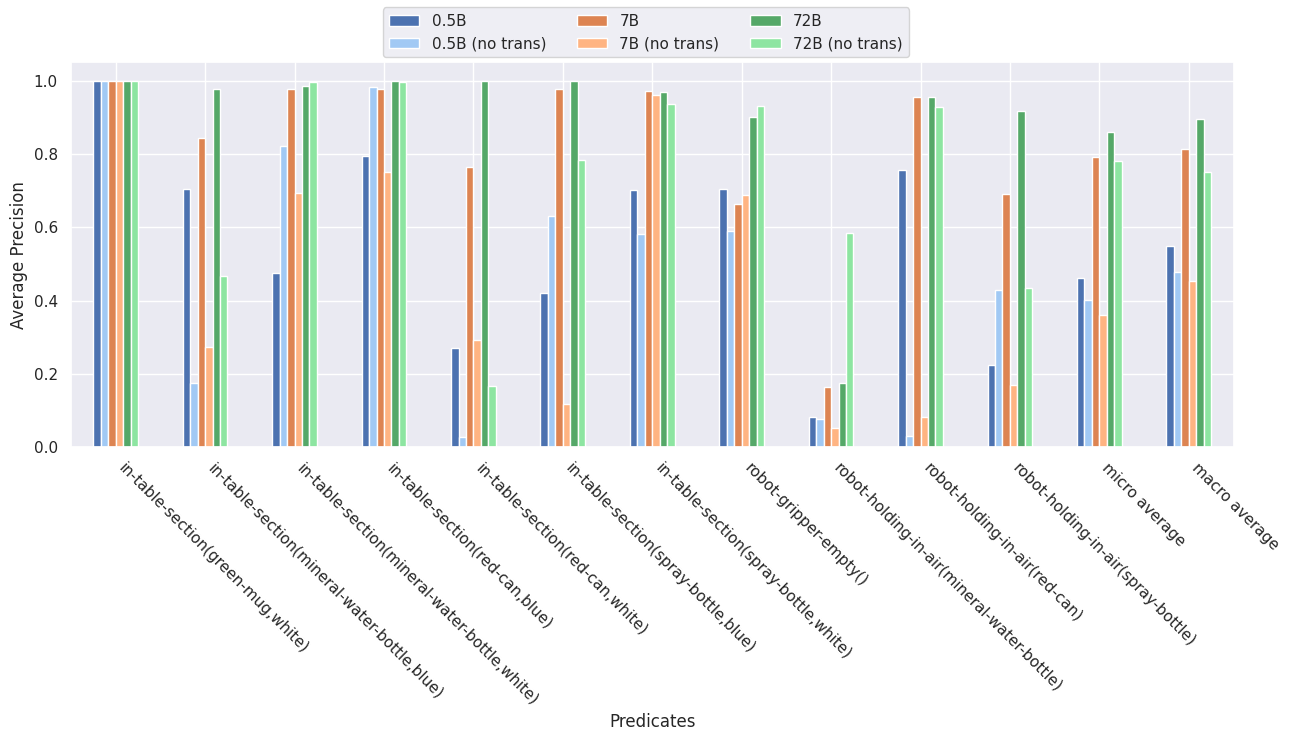

In [10]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision)
ap_pd = ap_pd[['0.5B', '0.5B (no trans)', '7B', '7B (no trans)', '72B', '72B (no trans)']]
ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns], rot=0)

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

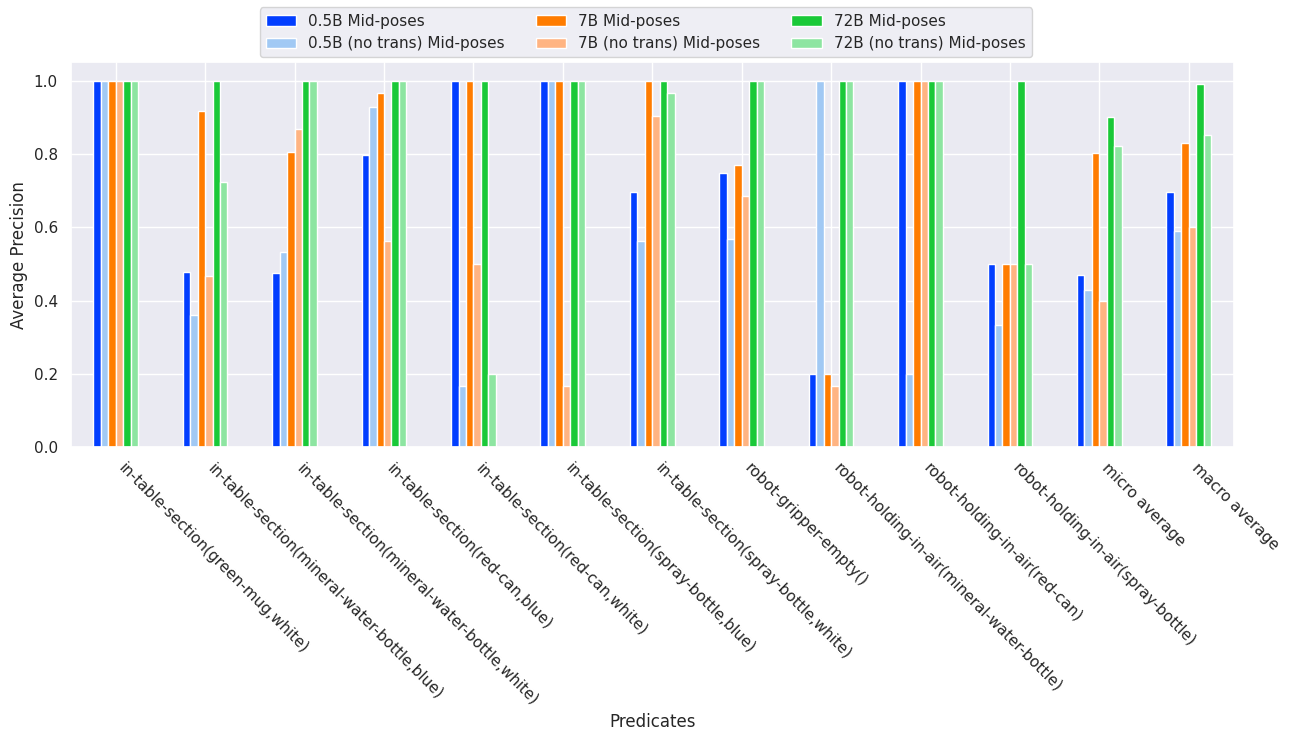

In [11]:
fig, ax = plt.subplots(figsize=(15, 5))
ap_pd = pd.DataFrame.from_dict(average_precision)
ap_pd = ap_pd[['0.5B Mid-poses', '0.5B (no trans) Mid-poses', '7B Mid-poses', '7B (no trans) Mid-poses', '72B Mid-poses', '72B (no trans) Mid-poses']]
ap_pd.plot.bar(legend=False, ax=ax, color=[color_map[c] for c in ap_pd.columns])

ax.set_ylabel('Average Precision')
ax.set_xlabel('Predicates')
plt.xticks(ha='left', rotation=-45)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3)

In [12]:
table = pd.DataFrame.from_dict({
    'Accuracy ($\theta = 0.3$)': {k: v['average'][30] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.5$)': {k: v['average'][50] for k, v in accuracy.items()},
    'Accuracy ($\theta = 0.7$)': {k: v['average'][70] for k, v in accuracy.items()},
    'AP Score (micro)': {k: v['micro average'] for k, v in average_precision.items()},
    'AP Score (macro)': {k: v['macro average'] for k, v in average_precision.items()},
}).T[[
    '0.5B', '0.5B (no trans)',
    '7B', '7B (no trans)',
    '72B', '72B (no trans)',
    '0.5B Mid-poses', '0.5B (no trans) Mid-poses',
    '7B Mid-poses', '7B (no trans) Mid-poses',
    '72B Mid-poses', '72B (no trans) Mid-poses',
]]

table.T

,Accuracy ($\theta = 0.3$),Accuracy ($\theta = 0.5$),Accuracy ($\theta = 0.7$),AP Score (micro),AP Score (macro)
0.5B,0.579421,0.634519,0.666411,0.462395,0.549878
0.5B (no trans),0.465996,0.600938,0.644509,0.401569,0.478582
7B,0.783755,0.773842,0.764159,0.791457,0.814554
7B (no trans),0.439253,0.490048,0.536464,0.359757,0.453407
72B,0.806578,0.806501,0.816030,0.860954,0.894706
72B (no trans),0.664566,0.696765,0.723430,0.781792,0.750240
0.5B Mid-poses,0.560440,0.626374,0.659341,0.469814,0.696932
0.5B (no trans) Mid-poses,0.505495,0.582418,0.659341,0.428285,0.589645
7B Mid-poses,0.725275,0.769231,0.769231,0.801334,0.830088
7B (no trans) Mid-poses,0.461538,0.527473,0.560440,0.399681,0.601382


In [ ]:
print(table.T.to_latex(float_format="%.2f").replace('\t', '\\t'))